# Worksheet: Detección de anomalías con Isolation Forest

## Configuración del entorno

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16.0, 6.0)
import sklearn

# Probando con datos reales

## Isolation Forest
El algoritmo Isolation Forest es un algoritmo de AD basado en árboles. Construye un determinado número de árboles aleatorios y su idea principal es que si una observación es una anomalía, entonces debería aparecer aislada en la hoja de un árbol tras algunas particiones. El Isolation Forest deriva una puntuación de anormalidad basada en la profundidad del árbol en la cuál tenemos las observaciones anómalas.

In [2]:
from sklearn.ensemble import IsolationForest

## One-Class SVM

Además de `IsolationForest`, vamos a aplicar `OneClassSVM`. La idea es la misma desde el punto de vista experimental: dentro de un mismo dígito, por ejemplo los cincos, se buscan las imágenes más atípicas. En este caso, el modelo aprende una frontera de normalidad mediante un kernel RBF y asigna puntuaciones de anormalidad a cada imagen.

In [3]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### Aplicación al dataset de dígitos
Ahora vamos a aplicar el IsolationForest para intentar localizar dígitos que han sido escritos de modo poco convencional.

In [4]:
from sklearn import datasets
digits = datasets.load_digits()

El algoritmo *Isolation Forest* es un algoritmo de AD basado en árboles. Construye un determinado número de árboles aleatorios y su idea principal es que si un ejemplo es una anomalía, entonces debería aparecer aislado en la hoja de un árbol tras algunas particiones. El *Isolation Forest* deriva una puntuación de anormalidad basada en la profundidad del árbol en la cuál términos los ejemplos anómalos.

In [5]:
images = digits.images
labels = digits.target
images.shape

(1797, 8, 8)

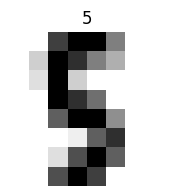

In [6]:
i = 102

plt.figure(figsize=(2, 2))
plt.title('{0}'.format(labels[i]))
plt.axis('off')
plt.imshow(images[i], cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

Para usar las imágenes como patrones de entrenamiento, tenemos que pasarlas a vector:

In [7]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

In [8]:
data.shape

(1797, 64)

In [9]:
X = data
y = digits.target

In [10]:
X.shape

(1797, 64)

Vamos a centrarnos en el dígito 5.

In [11]:
X_5 = X[y == 5]

In [12]:
X_5.shape

(182, 64)

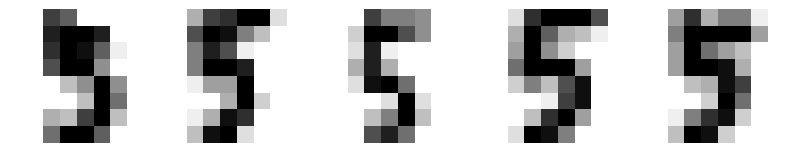

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(10, 4))
for ax, x in zip(axes, X_5[:5]):
    img = x.reshape(8, 8)
    ax.imshow(img, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

Vamos a usar ``IsolationForest`` para encontrar el 5% de imágenes más anómalas y representarlas:

In [14]:
from sklearn.ensemble import IsolationForest
iforest = IsolationForest(contamination=0.05)
iforest = iforest.fit(X_5)

Sacamos el grado de anormalidad utilizando `iforest.decision_function`. Cuanto más bajo, más anómalo.

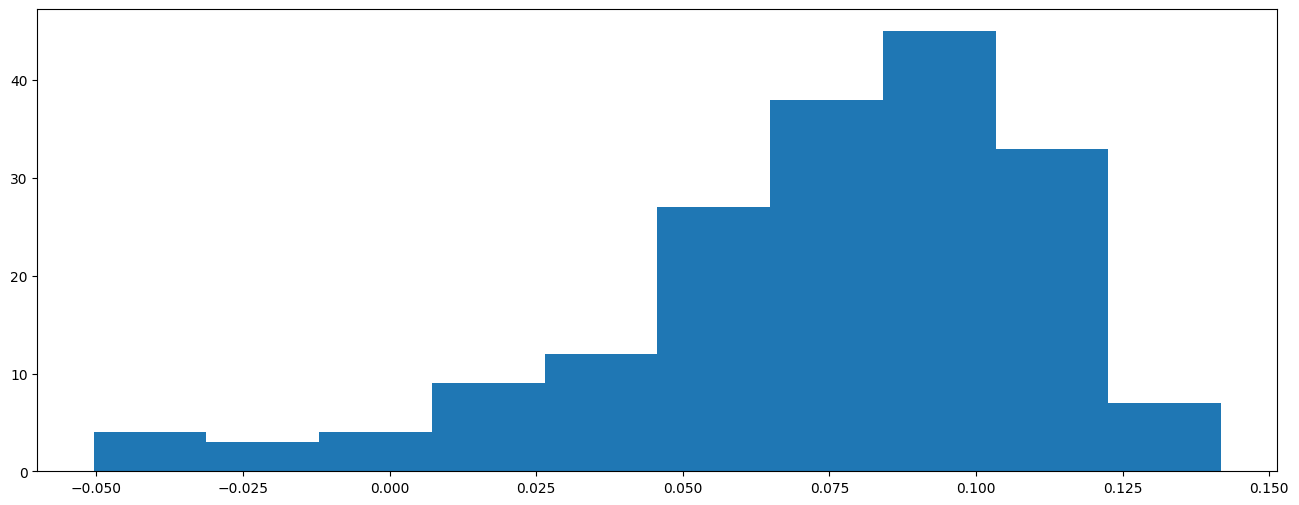

In [15]:
iforest_X = iforest.decision_function(X_5)
plt.hist(iforest_X);

Dibujemos los 10 ejemplos más "normales" (*inliers*):

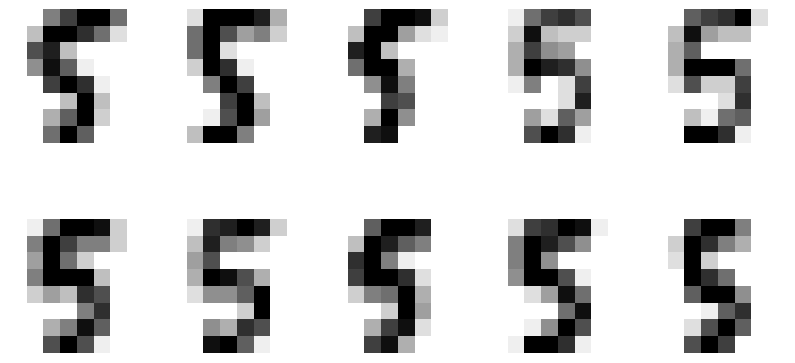

In [16]:
X_strong_inliers = X_5[np.argsort(iforest_X)[-10:]]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in zip(range(len(X_strong_inliers)), axes.ravel()):
    ax.imshow(X_strong_inliers[i].reshape((8, 8)),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

Ahora vamos a dibujar los *outliers*:

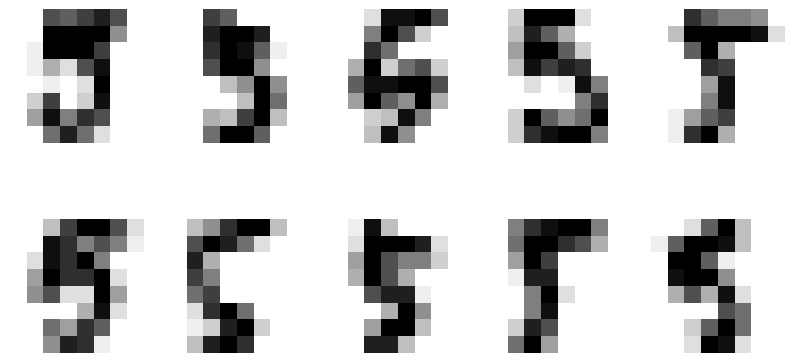

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

X_outliers = X_5[np.argsort(iforest_X)[:10]]

for i, ax in zip(range(len(X_outliers)), axes.ravel()):
    ax.imshow(X_outliers[i].reshape((8, 8)),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

## Aplicación de One-Class SVM al dígito 5

Ahora repetimos el análisis anterior usando `OneClassSVM`. En este caso, cada imagen se considera como un vector de 64 píxeles. Como OCSVM es sensible a la escala de las variables, se incluye un escalado previo mediante `StandardScaler`.

En `scikit-learn`, `decision_function` devuelve valores más altos para observaciones más normales y valores más bajos para observaciones más anómalas. Por tanto, al igual que con Isolation Forest, los ejemplos más atípicos serán los que tengan menor valor de `decision_function`.

In [18]:
ocsvm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", OneClassSVM(kernel="rbf", gamma="scale", nu=0.05))
])

ocsvm = ocsvm.fit(X_5)

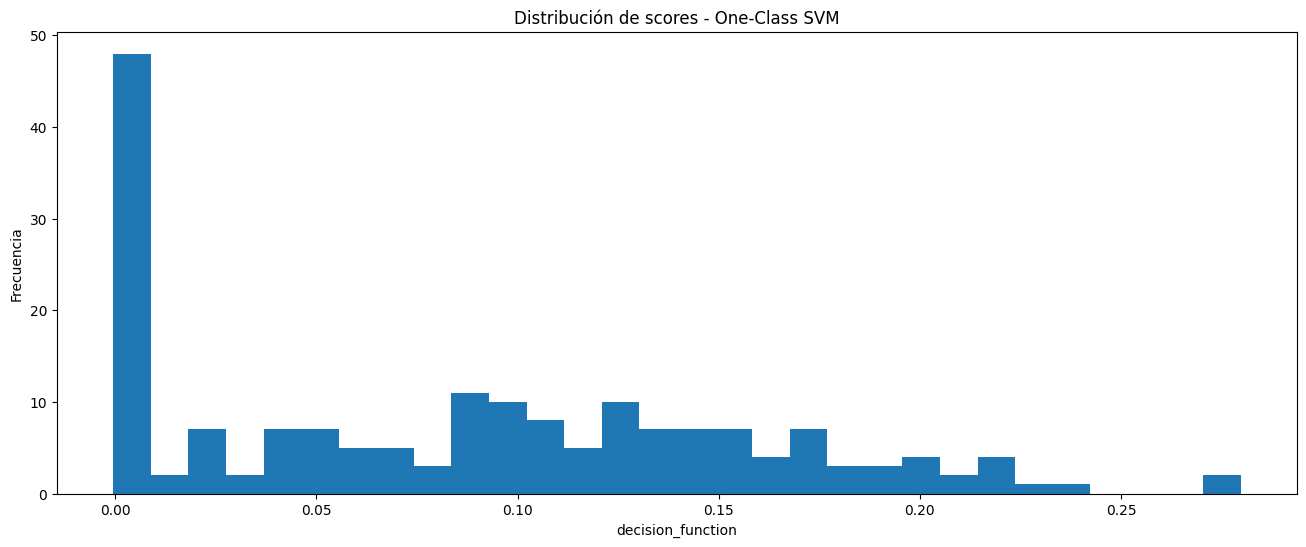

In [19]:
ocsvm_X = ocsvm.decision_function(X_5)

plt.hist(ocsvm_X, bins=30)
plt.title("Distribución de scores - One-Class SVM")
plt.xlabel("decision_function")
plt.ylabel("Frecuencia")
plt.show()

Dibujamos los 10 ejemplos más normales según One-Class SVM, es decir, aquellos con mayor valor de `decision_function`.

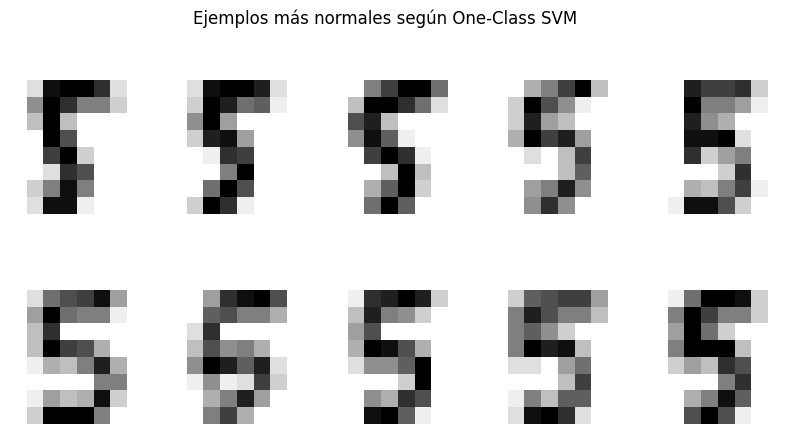

In [20]:
X_ocsvm_strong_inliers = X_5[np.argsort(ocsvm_X)[-10:]]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in zip(range(len(X_ocsvm_strong_inliers)), axes.ravel()):
    ax.imshow(X_ocsvm_strong_inliers[i].reshape((8, 8)),
              cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

plt.suptitle("Ejemplos más normales según One-Class SVM")
plt.show()

Dibujamos ahora los 10 ejemplos más anómalos según One-Class SVM, es decir, aquellos con menor valor de `decision_function`.

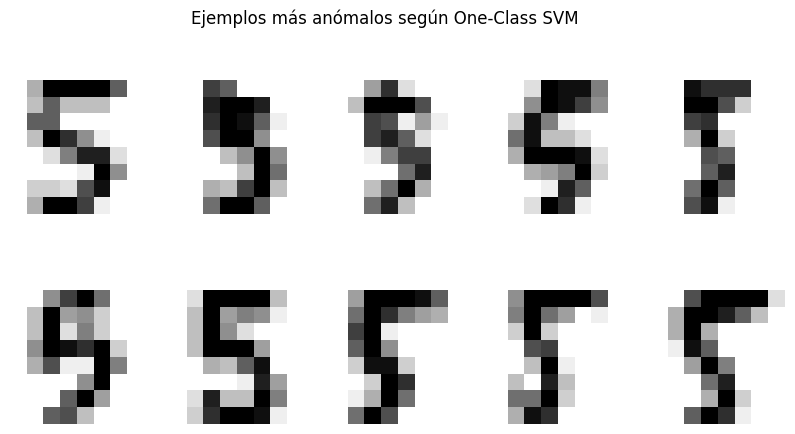

In [21]:
X_ocsvm_outliers = X_5[np.argsort(ocsvm_X)[:10]]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in zip(range(len(X_ocsvm_outliers)), axes.ravel()):
    ax.imshow(X_ocsvm_outliers[i].reshape((8, 8)),
              cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

plt.suptitle("Ejemplos más anómalos según One-Class SVM")
plt.show()

## Comparación automática para cualquier dígito

La siguiente función permite repetir el experimento para cualquier dígito. Para cada dígito se entrenan ambos modelos, se calculan los scores y se representan los ejemplos más normales y más anómalos según cada método.

In [22]:
def plot_digit_anomalies(digit, n_examples=10, contamination=0.05, nu=0.05):
    X_digit = X[y == digit]

    # Isolation Forest
    iforest = IsolationForest(contamination=contamination, random_state=42)
    iforest.fit(X_digit)
    if_scores = iforest.decision_function(X_digit)

    # One-Class SVM
    ocsvm = Pipeline([
        ("scaler", StandardScaler()),
        ("model", OneClassSVM(kernel="rbf", gamma="scale", nu=nu))
    ])
    ocsvm.fit(X_digit)
    svm_scores = ocsvm.decision_function(X_digit)

    methods = [
        ("Isolation Forest", if_scores),
        ("One-Class SVM", svm_scores)
    ]

    for method_name, scores in methods:
        normal_examples = X_digit[np.argsort(scores)[-n_examples:]]
        anomalous_examples = X_digit[np.argsort(scores)[:n_examples]]

        fig, axes = plt.subplots(2, n_examples, figsize=(1.5*n_examples, 3))

        for j in range(n_examples):
            axes[0, j].imshow(normal_examples[j].reshape(8, 8),
                              cmap=plt.cm.gray_r, interpolation='nearest')
            axes[0, j].axis('off')
            axes[1, j].imshow(anomalous_examples[j].reshape(8, 8),
                              cmap=plt.cm.gray_r, interpolation='nearest')
            axes[1, j].axis('off')

        axes[0, 0].set_ylabel("Normales", fontsize=12)
        axes[1, 0].set_ylabel("Anómalos", fontsize=12)
        plt.suptitle(f"{method_name} - Dígito {digit}")
        plt.show()

        print(f"{method_name} - Dígito {digit}")
        print(f"Score medio: {scores.mean():.4f}")
        print(f"Score mínimo: {scores.min():.4f}")
        print(f"Score máximo: {scores.max():.4f}")
        print("-" * 50)

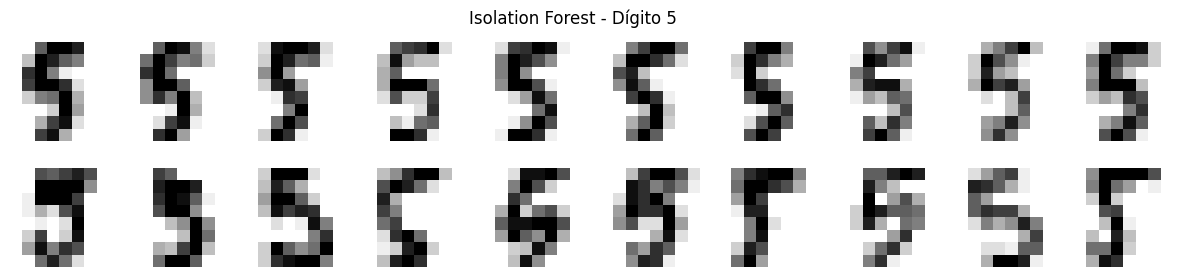

Isolation Forest - Dígito 5
Score medio: 0.0699
Score mínimo: -0.0739
Score máximo: 0.1257
--------------------------------------------------


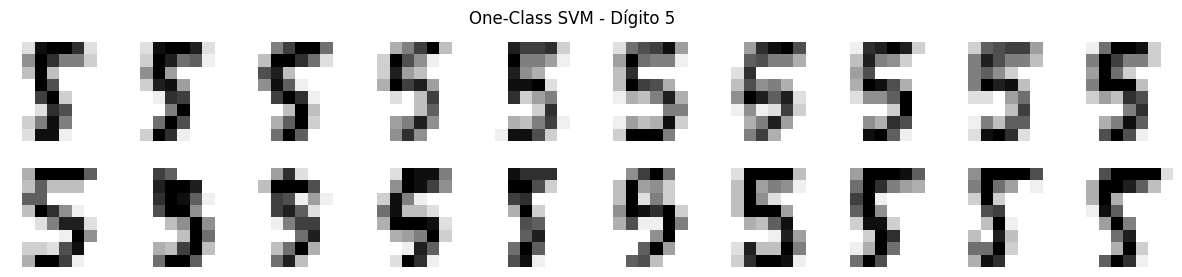

One-Class SVM - Dígito 5
Score medio: 0.0855
Score mínimo: -0.0005
Score máximo: 0.2797
--------------------------------------------------


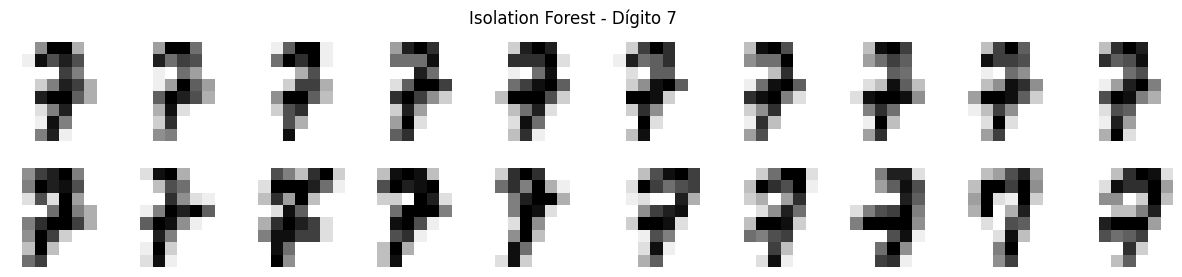

Isolation Forest - Dígito 7
Score medio: 0.1038
Score mínimo: -0.0511
Score máximo: 0.1799
--------------------------------------------------


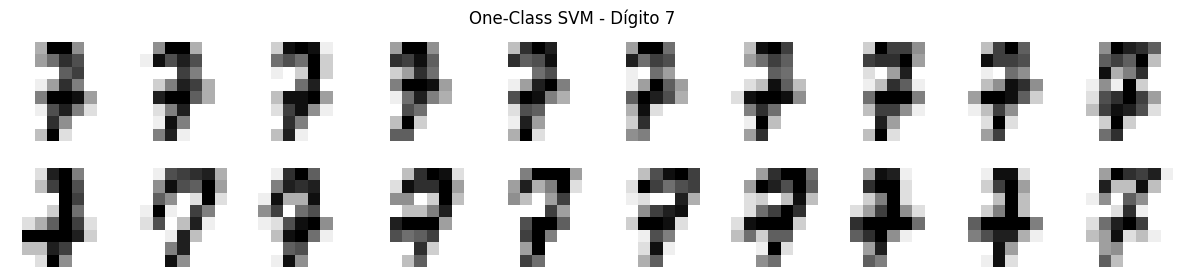

One-Class SVM - Dígito 7
Score medio: 0.0701
Score mínimo: -0.0004
Score máximo: 0.2576
--------------------------------------------------


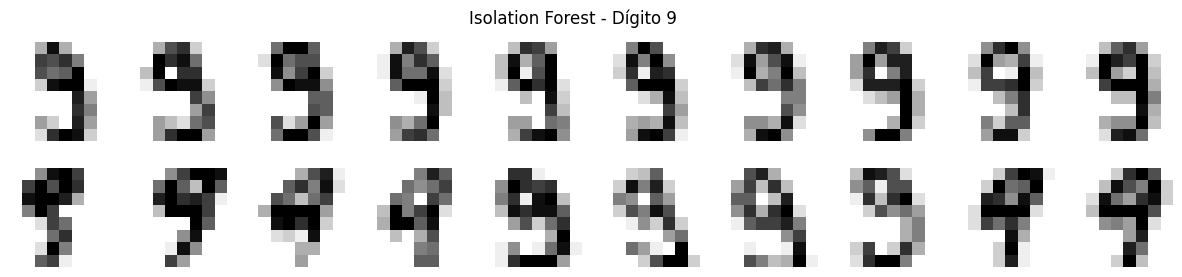

Isolation Forest - Dígito 9
Score medio: 0.0745
Score mínimo: -0.0570
Score máximo: 0.1383
--------------------------------------------------


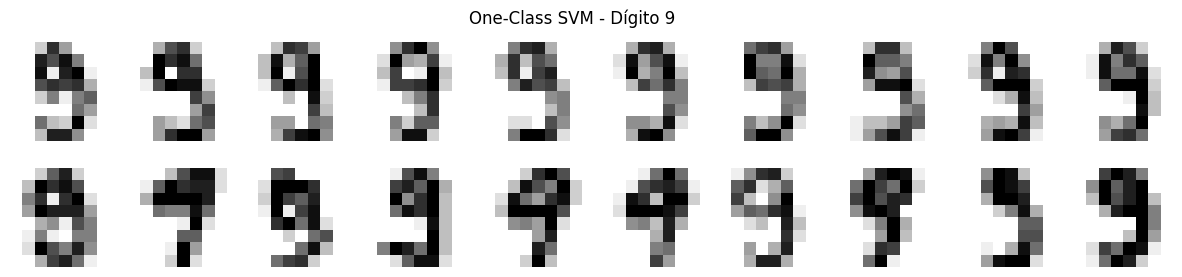

One-Class SVM - Dígito 9
Score medio: 0.0966
Score mínimo: -0.0004
Score máximo: 0.2828
--------------------------------------------------


In [23]:
# Ejemplos: repetir para los dígitos 5, 7 y 9
plot_digit_anomalies(5, n_examples=10)
plot_digit_anomalies(7, n_examples=10)
plot_digit_anomalies(9, n_examples=10)

## Interpretación

Este experimento no busca clasificar los dígitos, ya que las etiquetas solo se utilizan para seleccionar un subconjunto de imágenes del mismo número. El objetivo es detectar, dentro de una misma clase, cuáles son las imágenes más atípicas o peor escritas.

- Isolation Forest identifica imágenes que se aíslan rápidamente mediante particiones aleatorias.
- One-Class SVM identifica imágenes que quedan más alejadas de la región de normalidad aprendida mediante el kernel RBF.

Por tanto, los ejemplos más anómalos no son necesariamente errores de clasificación, sino observaciones cuya forma se aleja del patrón habitual dentro del dígito considerado.